In [24]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from copy import copy
from skimage.filters import gaussian, median
import xarray as xr

import sys
sys.path.append('..')
from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

In [8]:
data_folder = "/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/Ximea_Calibration"
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))

In [9]:
image_size = 12
masks = M_F.get_masks(size_x=image_size, size_y=image_size)
R, G, B, wavelength = S_F.getpixelefficiency()
wavelength = wavelength
pixel_QYs = np.vstack([B, G, R])
camera_parameters = {}
camera_parameters["gain"] = np.full((image_size, image_size), np.median(gain))
camera_parameters["offset"] = np.full((image_size, image_size), np.median(offset))
camera_parameters["variance"] = np.full((image_size, image_size), np.median(variance))
camera_parameters["readnoise"] = np.full((image_size, image_size), np.median(readnoise))
camera_parameters["rqe"] = np.full((image_size, image_size), np.median(rqe))
camera_parameters["pixel_QYs"] = pixel_QYs
camera_parameters["pixel_order"] = ['B', 'G', 'R']
camera_parameters["pixel_order_indices"] = [0, 1, 2]
camera_parameters["masks"] = masks

In [ ]:
n_photon_space = np.arange(500, 1300, 100)
n_bootstrap = 1000
background_photons = 4
pixel_size = 69
NA = 1.49

In [55]:
import types
fitter = types.SimpleNamespace()
fitter.default_params = np.array(["xc", "yc", "A", "sigma", "b", "peak"])
fitter.fit_function = I_AF.WLS_fit_nilered
smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma" :  1.5}
smoothing_function.extent =  1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [68]:
central_wavelengths = np.arange(575, 701)[::-1]
skew = 1.2
width = 30

In [69]:
notch_filter = 'semrock-nf03-405-488-561-635e'
dichroic_mirror = 'semrock-di01-r488-561'
nilered_filter = 'semrock-ff01-650-200-25'
shortpass_filter = 'semrock-bsp01-785r'
filters = [dichroic_mirror]
filter_data = np.prod(S_F.get_dye_or_filter_data(filters, wavelength, dye_or_filter=False), axis=0)

In [70]:
nilered_params = {'filter_data' : filter_data,
                  'width' : width,
                  'skew' : skew,
                  'wavelength': wavelength,
                  'pixel_QYs' : pixel_QYs}

In [59]:
save_folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Simulation/20250522_NileRed'
if not os.path.isdir(save_folder):
    os.makedirs(save_folder)

In [71]:
for mu in central_wavelengths:
    print("Analysing central wavelength {}".format(mu), end="\r",flush=True,)
    dye = 'simulated_nilered_mu_'+str(np.around(mu, 2)).zfill(6)
    params = [mu, width, skew]
    spectrum = S_F.skew_gaussian_model(params, wavelength)*filter_data
    spectrum = spectrum/np.sum(spectrum)
    data = {"wavelength": wavelength, "spectrum": spectrum}
    to_save = pl.DataFrame(data)
    to_save.write_csv(os.path.join(save_folder, 'NileRed_Spectrum_Nofilter_mu_'+str(np.around(mu, 2)).zfill(6)+'_width_'+str(np.around(width, 2)).zfill(6)+'_skew_'+str(np.around(skew, 2)).zfill(6)+'.csv'))

In [ ]:
for mu in central_wavelengths:
    print("Analysing central wavelength {}".format(mu), end="\r",flush=True,)
    dye = 'simulated_nilered_mu_'+str(np.around(mu, 2)).zfill(6)
    params = [mu, width, skew]
    spectrum = S_F.skew_gaussian_model(params, wavelength)*filter_data
    fitter.single_dye_spectrum = spectrum/np.sum(spectrum)
    fitter.dye_library = spectrum/np.sum(spectrum)
    nilered_params['mu'] = mu
    MSF.test_peak_fit_method(
                            dye,
                            filters,
                            wavelength,
                            camera_parameters,
                            fitter,
                            smoothing_function,
                            save_folder,
                            n_photon_space,
                            n_bootstrap=n_bootstrap,
                            nilered_params=nilered_params,
                            background_photons=background_photons,
                            NA=NA,
                            pixel_size=pixel_size,
                            cpu_fraction=1,
                        )

In [3]:
results_folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Simulation/20250522_NileRed'

In [78]:
results_files = os.listdir(results_folder)
files = np.sort([os.path.join(results_folder, x) for x in results_files if 'NileRed_Spectrum_Nofilter_mu_' in x and 'Spectrum' in x])

In [73]:
file_zero = pl.read_csv(files[0])

In [74]:
spectra = np.zeros([len(files), len(file_zero['wavelength'])])

In [79]:
for i, file in enumerate(files):
    spectra[i, :] = pl.read_csv(file)['spectrum'].to_numpy()
    print(np.sum(spectra[i, :]))

1.0
0.9999999999999999
1.0000000000000002
0.9999999999999998
1.0
0.9999999999999999
1.0
0.9999999999999998
1.0
1.0
1.0
1.0
1.0
1.0
1.0
0.9999999999999999
1.0
1.0
1.0
1.0
1.0000000000000002
0.9999999999999999
0.9999999999999998
1.0000000000000002
1.0
0.9999999999999999
1.0
1.0000000000000002
1.0
1.0
1.0000000000000002
1.0000000000000002
1.0
1.0
1.0
0.9999999999999999
1.0
1.0
1.0
1.0
0.9999999999999999
0.9999999999999999
1.0
1.0
1.0
1.0000000000000002
1.0
1.0
1.0
1.0000000000000002
1.0
0.9999999999999999
1.0
0.9999999999999998
0.9999999999999999
1.0
0.9999999999999999
1.0000000000000002
1.0000000000000002
0.9999999999999998
1.0
1.0
1.0
1.0
0.9999999999999998
0.9999999999999999
1.0
1.0000000000000002
0.9999999999999999
1.0
0.9999999999999999
0.9999999999999999
1.0
1.0
0.9999999999999999
1.0
1.0
1.0
1.0
0.9999999999999998
1.0
1.0
1.0
1.0
1.0000000000000002
0.9999999999999998
1.0
0.9999999999999999
0.9999999999999999
1.0
0.9999999999999999
1.0000000000000002
1.0000000000000002
0.99999999999

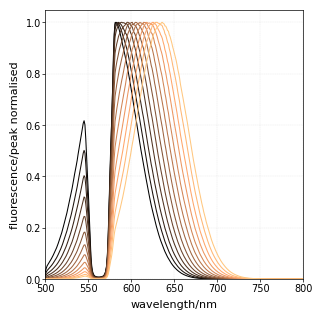

In [80]:
fig, axs = plotter.one_column_plot()

import matplotlib.pyplot as plot

linrange = np.arange(0, 126, 10)
n = len(linrange)
colors = plot.cm.copper(np.linspace(0,1,n))

for i, j in enumerate(linrange):
    axs = plotter.line_plot(axs=axs, x=wavelength, y=spectra[j, :]/np.max(spectra[j, :]), color=colors[i], xaxislabel='wavelength/nm', yaxislabel='fluorescence/peak normalised')

axs.set_ylim([0, 1.05])
axs.set_xlim([500, 800])

folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20250424/fig/multicolour/nile_red/'
plt.savefig(os.path.join(folder, 'nilered_examplespectra_nofilter_noskew.svg'), dpi=600, format='svg')

In [81]:
dye_efficiencies = np.zeros([3, 126])
average_wavelengths = np.zeros([126])
for i, j in enumerate(files):
    average_wavelengths[i], dye_efficiencies[:, i] = (
                    S_F.get_pixel_fractions_rawspectra(
                        spectra[i, :],
                        wavelength,
                        camera_parameters["pixel_QYs"],
                    )
                )


IndexError: index 126 is out of bounds for axis 0 with size 126

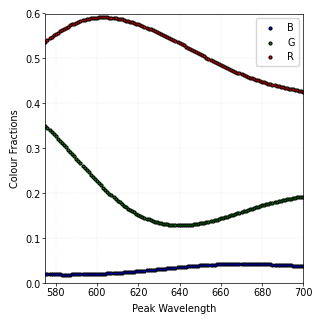

In [67]:
fig, axs = plotter.one_column_plot()

wavelengthspace = np.arange(575, 701)

axs = plotter.scatter_plot(axs=axs, x=wavelengthspace, y=dye_efficiencies[0, :], facecolor='blue', label='B')
axs = plotter.scatter_plot(axs=axs, x=wavelengthspace, y=dye_efficiencies[1, :], facecolor='green', label='G')
axs = plotter.scatter_plot(axs=axs, x=wavelengthspace, y=dye_efficiencies[2, :], facecolor='red', yaxislabel='Colour Fractions', label='R',
                          xaxislabel='Peak Wavelength')

axs.set_ylim([0, 0.6])
axs.legend(loc='best')

folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20250424/fig/multicolour/nile_red/'
plt.savefig(os.path.join(folder, 'nilered_colourfractions_nofilter.svg'), dpi=600, format='svg')

In [34]:
dye_pixel_efficiency

array([0.03837523, 0.18819372, 0.43298532])

In [ ]:
photons = file_zero['n_photons'].to_numpy()

In [ ]:
array = np.zeros([len(photons), len(files)])

In [ ]:
results_files = os.listdir(results_folder)
files = np.sort([os.path.join(results_folder, x) for x in results_files if 'fitter_WLS_fit_nilered_smoothingfunction' in x and 'std' in x])
array_std = np.zeros([len(photons), len(files)])
for i, file in enumerate(files):
    array_std[:, i] = pl.read_csv(file)['peak'].to_numpy()

In [ ]:
for i, file in enumerate(files):
    array[:, i] = pl.read_csv(file)['peak'].to_numpy()

In [ ]:
fig, ax = plotter.two_column_plot(ncolumns=2, widthratio=[1,1])
from matplotlib.colors import LogNorm
Z = array

axs=ax[0]
cbarlabel = 'Nile Red Peak RMSE/nm'
im = axs.imshow(Z, cmap='viridis', origin='lower', aspect='auto', norm=LogNorm(vmin=3, vmax=110))
cbar = plt.colorbar(im, fraction=0.045, pad=0.02, ax=axs, location="right")
cbar.set_label(cbarlabel, rotation=90, labelpad=1, fontsize=8)
cbar.ax.tick_params(labelsize=7, pad=0.1, width=0.5, length=2)
axs.set_xticks(np.arange(575, 701, 20)-575)
axs.set_xticklabels(np.arange(575, 701, 20))

axs.set_yticks(np.arange(0, len(photons), 2))
real_y = np.asarray(photons[np.arange(0, len(photons), 2)], dtype=int)
axs.set_yticklabels(np.around(real_y, 1))
axs.set_ylabel(r'photons', fontsize=8)

axs.vlines(x=620-575, ymin=-5, ymax=10, ls='--', color='k')
axs.set_ylim([0, 7])

axs=ax[1]
Z = array_std
cbarlabel = r'Nile Red Peak $\sigma$/nm'
im = axs.imshow(Z, cmap='viridis', origin='lower', aspect='auto', norm=LogNorm(vmin=3, vmax=110))
cbar = plt.colorbar(im, fraction=0.045, pad=0.02, ax=axs, location="right")
cbar.set_label(cbarlabel, rotation=90, labelpad=1, fontsize=8)
cbar.ax.tick_params(labelsize=7, pad=0.1, width=0.5, length=2)
axs.set_xticks(np.arange(575, 701, 20)-575)
axs.set_xticklabels(np.arange(575, 701, 20))

axs.set_yticks(np.arange(0, len(photons), 2))
real_y = np.asarray(photons[np.arange(0, len(photons), 2)], dtype=int)
axs.set_yticklabels([])

folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20250424/fig/multicolour/nile_red/'
plt.savefig(os.path.join(folder, 'nilered_fittingerror.svg'), dpi=600, format='svg')